(sec:SomeFrequentistConnections)=
# Some frequentist connections

## $\chi^2$/dof for model assessment and comparison  

Many physicists learn to judge whether a fit of a model to data is good or to pick out the best fitting model among several by evaluating the $\chi^2$/dof (dof = "degrees of freedom") for a given model and comparing the result to one. Here $\chi^2$ is the sum of the squares of the residuals (data minus model predictions) divided by variance of the error at each point:

$$
  \chi^2 \equiv \sum_{i=1}^{N_{\text{data}}} \frac{\bigl(y_i - f(x_i;\hat\pars)\bigr)^2}{\sigma_i^2} ,
$$

where $y_i$ is the $i^{\text th}$ data point, $f(x_i;\hat\pars)$ is the prediction of the model for that point using the best fit for the parameters, $\hat\pars$, and $\sigma_i$ is the error bar for that data point. The degrees-of-freedom (dof), often denoted by $\nu$, is the number of data points minus number of fitted parameters:

$$
  \nu = N_{\text{data}} - N_{\text{fit parameters}} .
$$ 

The rule of thumb is generally that $\chi^2/\text{dof} \gg 1$ means a poor fit and $\chi^2/\text{dof} < 1$ indicates overfitting.
*Where does this come from and under what conditions is it a statistically valid thing to analyze fit models this way?*
(Note that in contrast to the Bayesian evidence, we are not assessing the model in general, but a particular fit to the model identified by $\hat\pars$.)

Underlying this use of $\chi^2$/dof is a particular, familiar statistical model

$$
    y_{\text{expt}} = y_{\text{th}} + \delta y_{\text{expt}} + \delta y_{\text{th}}
$$

in which the theory is $y_{\text{th},i} = f(x_i;\hat\pars)$, the experimental error is  *independent* Gaussian distributed noise with mean zero and standard deviation $\sigma_i$, that is $\delta y_{\text{expt}} \sim \mathcal{N}(0,\Sigma)$ with $\Sigma_{ij} = \sigma_i^2 \delta_{ij}$, and $\delta y_{\text{th}}$ is neglected (i.e., no model discrepancy is included). The prior is (usually implicitly) taken to be uniform, so

$$
     y_{\text{expt}} \sim \mathcal{N}\bigl(f(x_i;\hat\pars), \Sigma\bigr) .
$$ 

The likelihood (and the posterior, with a uniform prior) is then proportional to $e^{-\chi^2(\hat\pars)/2}$.

According to this model, each term in $\chi^2$ before being squared is a draw from a *standard* normal distribution. In this context, "standard" means that the distribution has mean zero and variance 1. This is exactly what happens when we take as the random variables $\bigl(y_i - f(x_i;\hat\pars)\bigr)/\sigma_i$.
But the sum of the squares of $k$ *independent* standard normal random variables has a known distribution, called the $\chi^2$ distribution with $k$ degrees of freedom. 
So the sum of the normalized residuals squared should be distributed (if you generated many sets of them) as a $\chi^2$ distribution. How many degrees of freedom? This should be the number of independent pieces of information. But we have found the fitted parameters $\hat\pars$ by minimizing $\chi^2$, i.e., by setting $\partial \chi^2(\pars)/\partial \theta_j$ for $j = 1,\ldots,N_{\text{fit parameters}}$, which means $N_{\text{fit parameters}}$ constraints. Therefore the number of dofs is given by $\nu = N_{\text{data}} - N_{\text{fit parameters}}$.

Now what do we do with this information? We only have one draw from the (supposed) $\chi^2$ distribution. But if that distribution is narrow, we should be close to the mean. The mean of a $\chi^2$ distribution with $k = \nu$ dofs is $\nu$, with variance $2\nu$. 
So if we've got a good fit (and our statistical model is valid), then $\chi^2/\nu$ should be close to one. If it is much larger, than the conditions are not satisfied, so the model doesn't work. If it is smaller, than the failure implies that the residuals are too small, meaning overfitting.

But we should expect fluctuations, i.e., we shouldn't always get the mean (or the mode, which is $\nu - 2$ for $\nu\geq 0$). If $\nu$ is large enough, then the distribution is approximately Gaussian and we can use the standard deviation / dof or $\sqrt{2\nu}/\nu = \sqrt{2/\nu}$ as an expected width around one.
One might use two or three times $\sigma$ as a range to consider.
If there are 1000 data points, then $\sigma \approx 0.045$, so $0.91 \leq \chi^2/{\rm dof} \leq 1.09$ would be an acceptable range at the 95% confidence level ($2\sigma$). With fewer data points this range grows significantly.
**So in making the comparison of $\chi^2/\nu$ to one, be sure to take into account the width of the distribution, i.e., consider $\pm \sqrt{2/\nu}$ roughly.** For a small number of data points, do a better analysis!

What can go wrong? Lots! See
["Do's and Don'ts of reduced chi-squared"](https://arxiv.org/pdf/1012.3754.pdf) for a thorough discussion. But we've made assumptions that might not hold: that the data is Gaussian distributed and independent, that the data is dominated by experimental and not theoretical errors, and that the constraints from fitting are linearly independent. We've also assumed a lot of data and 
we've ignored informative (or, more precisely, non-uniform priors) priors.

### Test the sum of normal variables squared

The $\chi^2$ distribution is supposed to result from the sum of the squares of Gaussian random variables. Here we test it numerically for two values of the degrees of freedom (dof). (You can try other cases by copying the code into a Jupyter notebook.) The Gaussian (normal) random variables are drawn from a standard normal distribution, i.e., with mean $\mu = 0$ and $\sigma = 1$.

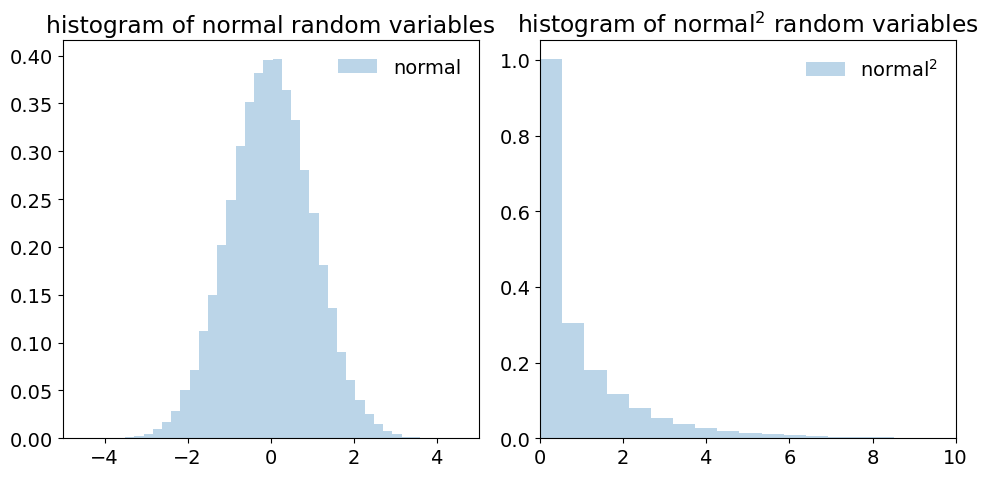

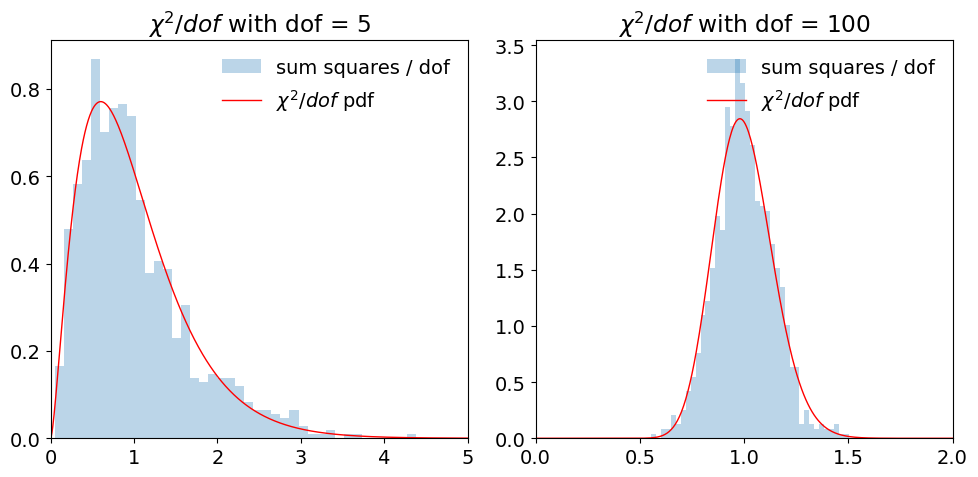

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
import scipy.stats as stats

# sample tot_vals normal variables
tot_vals = 100000
x_norm_vals = stats.norm.rvs(size=tot_vals, random_state=None)

# plot a histogram of the normal variables and then their squares
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].hist(x_norm_vals, bins=40, density=True, alpha=0.3, label='normal')
ax[0].set_xlim((-5, 5))
ax[0].legend(loc='best', frameon=False)
ax[0].set_title(fr'histogram of normal random variables')

ax[1].hist(x_norm_vals**2, bins=40, density=True, alpha=0.3, label=r'${\rm normal}^2$')
ax[1].legend(loc='best', frameon=False)
ax[1].set_title(fr'histogram of normal$^2$ random variables')
ax[1].set_xlim((0, 10))

fig.tight_layout()

def sum_norm_squares(num):
    """
    Return the sum of num random variables, with each the square of a random draw
    from a normal distribution
    """
    return np.sum(stats.norm.rvs(size=num, random_state=None)**2)

def histogram_per_dof(ax, num, x_min=0, x_max=5, tot_vals=1000):
    """
    Plot a histogram of sum of squares
      num --- number of squared normal-distributed random variables to sum
    """
    sum_xsq_vals = np.array([sum_norm_squares(num) for i in range(tot_vals)])
    scaled_sum = sum_xsq_vals/num
    ax.hist(scaled_sum, bins=40, density=True, alpha=0.3, 
        label='sum squares / dof')

    dofs = num
    x = np.linspace(0,5*dofs,1000)
    ax.plot(x/dofs, dofs*stats.chi2.pdf(x, dofs),
         'r-', lw=1, alpha=1, label=r'$\chi^2/dof$ pdf')

    ax.set_xlim((x_min, x_max))
    ax.legend(loc='best', frameon=False)
    ax.set_title(fr'$\chi^2/dof$ with dof = {dofs}')

    return ax

# Histograms per dof
tot_vals = 1000000  # no. of trials
fig, ax = plt.subplots(1, 2, figsize=(10,5))
num_lo = 5
ax[0] = histogram_per_dof(ax[0], num_lo, 0, 5)
num_hi = 100
ax[1] = histogram_per_dof(ax[1], num_hi, 0, 2)

fig.tight_layout()

Check whether the distributions (which are of $\chi^2/\nu$) are consistent with the statement above that the mean of a $\chi^2$ distribution with $k = \nu$ dofs is $\nu$, with variance $2\nu$. 

## p-values: when all you can do is falsify

A common way for a frequentist to discuss a theory/model, or put a
bound on a parameter value, is to quote a p-value.
This is set up using something called the null hypothesis. Somewhat
perversely you should pick the null hypothesis to be the opposite of
what you want to prove. So if you want to discover the Higgs boson,
the null hypothesis is that the Higgs boson does not exist.

Then you pick a level of proof you are comfortable with. For the
Higgs boson (and for many other particle physics experiments) it is
"5 sigma''. *How do you think we convert this statement to a
probability?* [Hint: refer to a Gaussian distribution.]
One minus the resulting probability is called the $p$-value. We will
denote it $p_{\rm crit}$. There is nothing
God-given about it. It is a standard (like "beyond a reasonable
doubt") that has been agreed upon in a research community for
determining that something is (likely) going on. 

You then take data and compute $p(D|{\rm null~hypothesis})$. If
$p(D|{\rm null~ hypothesis}) < p_{\rm crit}$ then you conclude that the "the null
hypothesis is rejected at the $p_{\rm crit}$ significance level''.
Note that if $p(D|{\rm null~hypothesis}) > p_{\rm crit}$ you cannot
conclude that the null hypothesis is true. It just means "no effect
was observed".

:::{admonition} Exercise
  Look at
  {ref}`demo:WidgetCoinTossing`. Pick
  a $p_{\rm crit}$-value. If  $p_h=0.4$, work out how many coin tosses it would take
  to reject the null hypothesis that it's a fair coin ($p_h=0.5$) at
  this significance level. 
:::



## Contrast Bayesian and significance analyses for coin flipping

Suppose we do a coin flipping experiment where we toss a coin 20 times and it comes up heads 14 times. Let's compare how we might analyze this with Bayesian methods to how we might do a significance analysis with p-values.

**Bayesian analysis.** 
Following our study in {ref}`demo:WidgetCoinTossing`, let's calculate the probability of heads, which we call $p_h$, given data $D = \{R \text{ heads}, N \text{ tosses}\}$. 
* Let's assume a uniform prior (encoded as a beta function with $\alpha=1$, $\beta=1$).
* We found that this can be expressed as a beta function, which we can calculate in Python using
$p(p_h|D) = p(D|p_h)p(p_h)$ $\longrightarrow$ `scipy.stats.beta.pdf(p_h,1+R,1+N-R)`. For $N=20$, $R=14$, this is shown on the left below.
* Now we can answer many questions, such as: what is the probability that $p_h$ is between $0.49$ and $0.51$? The answer comes from integrating our pdf over this interval (i.e., the area under the curve).
* Note that in the Bayesian analysis, the data is given while the probability of heads is a random value.

```{image} ../assets/beta_distribution_14heads_in_20tosses.png
:alt: bootstrapping
:class: bg-primary
:width: 700px
:align: center
```

**Significance test.** Here we will try to answer the question: Is the coin fair? We'll follow the discussion in Wikipedia under [p-value](https://en.wikipedia.org/wiki/P-value) titled "Testing the fairness of a coin". 
* We interpret "fair" as meaning $p_h = 0.5$. Our null hypothesis is that the coin is fair and $p_h = 0.5$.
* We plot the probabilities for getting $R$ heads in $N=20$ tosses using the binomial probability mass distribution on the right above.
* We decide on the significance $p_{\rm crit} = 0.05$.
* (Important conceptual question:) $p_{\rm crit}$ and $p_h$ are both probabilities. Turn to your neighbor and explain to them what they are the probabilities of and how they are different. 
* We need to find the probability of getting data *at least as extreme* as $D = \{R \text{ heads}, N \text{ tosses}\}$. For our example, that means adding up the binomial probabilities for $R = 14, 15, \ldots, 20$, which is 0.058. (This is called a "one-tailed test". If we wanted to consider deviations favoring tails as well, we would would add as well the probabilities for $R = 0, 1, \ldots, 6$, so $0.115$ in total. This would be a "two-tailed test".) 
* Comparing to $p_{\rm crit} = 0.05$, we find the p-value is greater than $p_{\rm crit}$, so the null hypothesis is not rejected at the 95\% level. (Note that we say "not rejected" as opposed to "accepted".) If we had gotten 15 heads instead we would have rejected the null hypothesis.
* Note that in this frequentist analysis, the *data* is random while $p_h$ is fixed (although unknown). 

:::{admonition} Exercise
  Verify that if we had gotten 15 heads in $N=20$ tosses that we would have rejected the null hypothesis.
:::




## Bayesian credible intervals and frequentist confidence intervals

We already commented on the difference between the
68% degree of belief interval for the most likely value (in that case
the bias weighting of the coin) and a frequentist $1 \sigma$ confidence
interval.

* First point is that $1 \sigma=68$% assumes a Gaussian distribution
  around the maximum of the posterior (cf. above). While this will
  often work out okay, it may not. And, as we seek to translate, 
  $n \sigma$ intervals into DoB statements, assuming a Gaussian
  becomes more and more questionable the higher $n$ is. (Why?)

* But the second point is more philosophical (meta-statistical?). One
  interval is a statement about $p(x|D,I)$, while the other is a
  statement about $p(D|x,I)$.

* (Note that because the conversion between the two pdfs requires the
 use of Bayes' theorem the Bayesian interval may be affected by the
 choice of the prior.)

* Bayesian version is easy; a 68% credible interval or Bayesian
  confidence interval or degree-of-belief (DoB) interval is: given
  some data and some information $I$, there is a 68% chance (probability) that the interval contains the true parameter. 

* Frequentist 68% confidence interval
    * Assuming the model (contained in $I$) and the value of the
      parameter $x$ then if we do the experiment a large number of
      times then 68% of them will produce data in that interval.
   * So the *parameter* is fixed (no pdf) and the confidence
     interval is a statement about data
   * Frequentists will try to make statements about parameters, but
     they end up a bit tangled, e.g., "There is a 68% probability
     that when I compute a confidence interval from data of this sort
     that the true value of $\theta$ will fall within the
     (hypothetical) space of observations."


* For a one-dimensional posterior that is symmetric, it is clear how to define the $d\%$ confidence interval. 
    * Algorithm: start from the center, step outward on both sides, stop when $d\%$ is enclosed.
    * For a two-dimensional posterior, need a way to integrate from the top. (Could lower a plane, as desribed below for HPD.)

* What if asymmetic or multimodal? Two of the possible choices:
    * Equal-tailed interval (central interval): the area above and below the interval are equal.
    * Highest posterior density (HPD) region: posterior density for
      every point is higher than the posterior density for any point
      outside the
      interval. [E.g., lower a horizontal line over the distribution until the desired interval percentage is covered by regions above the line.]